In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data Types:
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891

In [6]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [7]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Fill numerical missing values with median
df["age"] = df["age"].fillna(df["age"].median())

# Fill categorical missing values with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

# The deck column has many missing values, so remove it
df = df.drop(columns=["deck"])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [9]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

print("Categorical columns:")
print(categorical_columns.tolist())

# One-hot encode categorical variables
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("\nDataset after encoding:")
print(df_encoded.head())

print("\nNew shape:", df_encoded.shape)

Categorical columns:
['sex', 'embarked', 'class', 'who', 'embark_town', 'alive']

Dataset after encoding:
   survived  pclass   age  sibsp  parch     fare  adult_male  alone  sex_male  \
0         0       3  22.0      1      0   7.2500        True  False         1   
1         1       1  38.0      1      0  71.2833       False  False         0   
2         1       3  26.0      0      0   7.9250       False   True         0   
3         1       1  35.0      1      0  53.1000       False  False         0   
4         0       3  35.0      0      0   8.0500        True   True         1   

   embarked_Q  embarked_S  class_Second  class_Third  who_man  who_woman  \
0           0           1             0            1        1          0   
1           0           0             0            0        0          1   
2           0           1             0            1        0          1   
3           0           1             0            0        0          1   
4           0           1  

In [10]:
numerical_columns = ["age", "fare", "sibsp", "parch"]

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['age', 'fare', 'sibsp', 'parch']


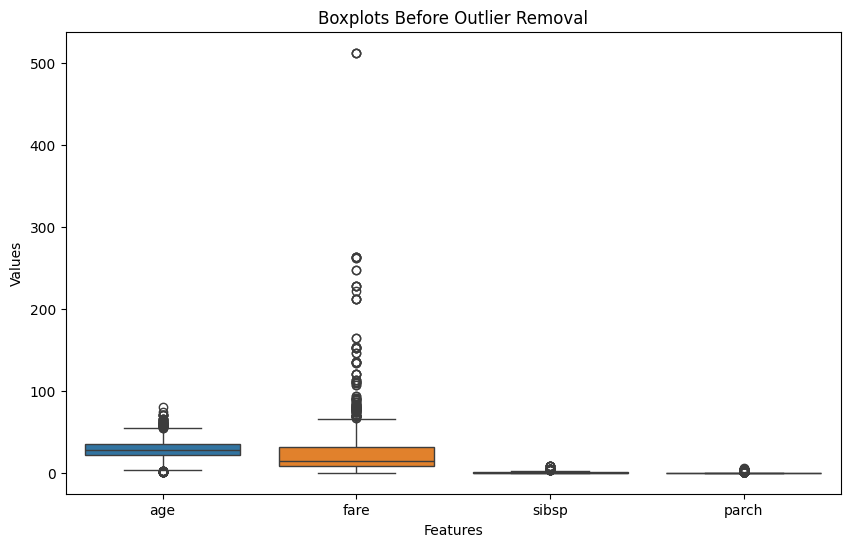

In [11]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_encoded[numerical_columns])

plt.title("Boxplots Before Outlier Removal")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

In [12]:
df_clean = df_encoded.copy()

for column in ["age", "fare"]:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[column] >= lower_limit) &
        (df_clean[column] <= upper_limit)
    ]

print("Original dataset shape:", df_encoded.shape)
print("Shape after outlier removal:", df_clean.shape)

Original dataset shape: (891, 18)
Shape after outlier removal: (718, 18)


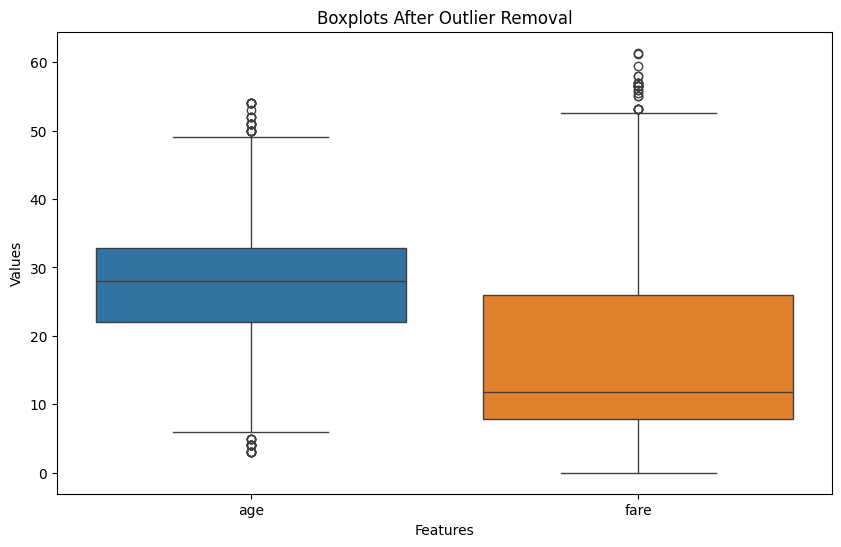

In [13]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_clean[["age", "fare"]])

plt.title("Boxplots After Outlier Removal")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_columns = ["age", "fare", "sibsp", "parch"]

df_clean[scale_columns] = scaler.fit_transform(df_clean[scale_columns])

print("Numerical features standardized successfully!")

display(df_clean.head())

Numerical features standardized successfully!


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton,alive_yes
0,0,3,-0.607611,0.686268,-0.40491,-0.751265,True,False,1,0,1,0,1,1,0,0,1,0
2,1,3,-0.207827,-0.484137,-0.40491,-0.700265,False,True,0,0,1,0,1,0,1,0,1,1
3,1,1,0.691688,0.686268,-0.40491,2.712961,False,False,0,0,1,0,0,0,1,0,1,1
4,0,3,0.691688,-0.484137,-0.40491,-0.690821,True,True,1,0,1,0,1,1,0,0,1,0
5,0,3,-0.007934,-0.484137,-0.40491,-0.659971,True,True,1,1,0,0,1,1,0,1,0,0


In [15]:
print("Final Dataset Shape:")
print(df_clean.shape)

print("\nRemaining Missing Values:")
print(df_clean.isnull().sum())

print("\nFinal Data Types:")
print(df_clean.dtypes)

print("\nFinal Dataset:")
display(df_clean.head())

Final Dataset Shape:
(718, 18)

Remaining Missing Values:
survived                   0
pclass                     0
age                        0
sibsp                      0
parch                      0
fare                       0
adult_male                 0
alone                      0
sex_male                   0
embarked_Q                 0
embarked_S                 0
class_Second               0
class_Third                0
who_man                    0
who_woman                  0
embark_town_Queenstown     0
embark_town_Southampton    0
alive_yes                  0
dtype: int64

Final Data Types:
survived                     int64
pclass                       int64
age                        float64
sibsp                      float64
parch                      float64
fare                       float64
adult_male                    bool
alone                         bool
sex_male                     int64
embarked_Q                   int64
embarked_S                   int64
cla

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton,alive_yes
0,0,3,-0.607611,0.686268,-0.40491,-0.751265,True,False,1,0,1,0,1,1,0,0,1,0
2,1,3,-0.207827,-0.484137,-0.40491,-0.700265,False,True,0,0,1,0,1,0,1,0,1,1
3,1,1,0.691688,0.686268,-0.40491,2.712961,False,False,0,0,1,0,0,0,1,0,1,1
4,0,3,0.691688,-0.484137,-0.40491,-0.690821,True,True,1,0,1,0,1,1,0,0,1,0
5,0,3,-0.007934,-0.484137,-0.40491,-0.659971,True,True,1,1,0,0,1,1,0,1,0,0


In [16]:
df_clean.to_csv("cleaned_titanic.csv", index=False)

print("cleaned_titanic.csv has been created successfully!")

cleaned_titanic.csv has been created successfully!
